##class learning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# to get rid of scientific notation
pd.options.display.float_format='{:.2f}'.format

In [ ]:
sales = pd.read_csv('qSales_2024.csv')
display(sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,102450,2022-12-31,2022,3,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2022Q4,2022Q3,5280.78,A
273,102450,2023-03-31,2022,4,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q1,2022Q4,2226.88,A
274,102450,2023-06-30,2023,1,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q2,2023Q1,3190.81,A
275,102450,2023-09-30,2023,2,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q3,2023Q2,2140.04,A


In [ ]:
AppleSales = sales.loc[sales['tic']=='AAPL']
AppleSales['datadate']=pd.to_datetime(AppleSales['datadate'])
display(AppleSales)

/tmp/ipykernel_10591/3417321933.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  AppleSales['datadate']=pd.to_datetime(AppleSales['datadate'])


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,1690,2022-12-31,2023,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2022Q4,2023Q1,117154.00,A
88,1690,2023-03-31,2023,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q1,2023Q2,94836.00,A
89,1690,2023-06-30,2023,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q2,2023Q3,81797.00,A
90,1690,2023-09-30,2023,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q3,2023Q4,89498.00,A


In [ ]:
AppleSales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92 entries, 0 to 91
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   gvkey     92 non-null     int64         
 1   datadate  92 non-null     datetime64[ns]
 2   fyearq    92 non-null     int64         
 3   fqtr      92 non-null     int64         
 4   fyr       92 non-null     int64         
 5   indfmt    92 non-null     object        
 6   consol    92 non-null     object        
 7   popsrc    92 non-null     object        
 8   datafmt   92 non-null     object        
 9   tic       92 non-null     object        
 10  conm      92 non-null     object        
 11  curcdq    92 non-null     object        
 12  datacqtr  92 non-null     object        
 13  datafqtr  92 non-null     object        
 14  saleq     92 non-null     float64       
 15  costat    92 non-null     object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(10)
memory usage: 

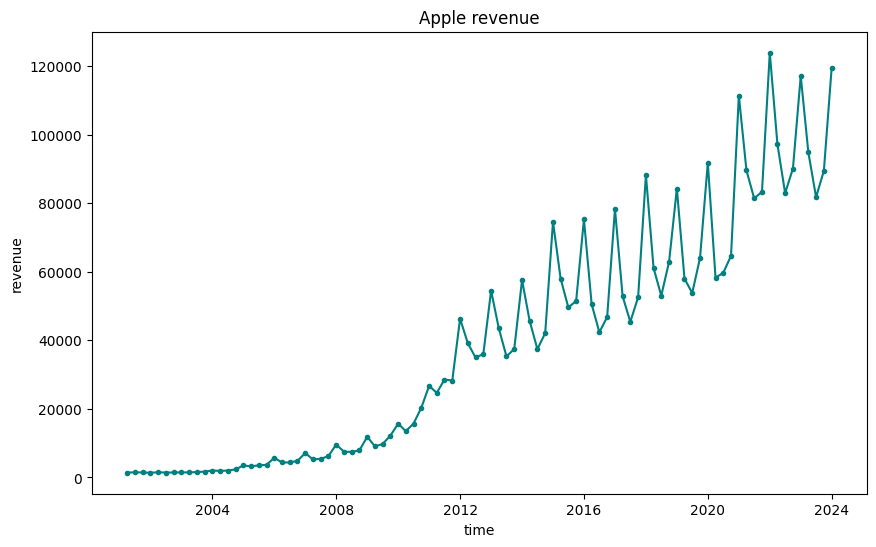

In [ ]:
#visualization initial
plt.figure(figsize=(10,6))

plt.title('Apple revenue')
plt.xlabel('time')
plt.ylabel('revenue')

plt.plot(AppleSales['datadate'],AppleSales['saleq'],marker='.', color='teal')

In [ ]:
# time series forecasting puts time as independent variable
#needs each row to be equal time periods

#how to add time column
AppleSales['time'] = range(1,len(AppleSales)+1)

display(AppleSales)

/tmp/ipykernel_10591/291771684.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  AppleSales['time'] = range(1,len(AppleSales)+1)


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A,1
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A,2
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A,3
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A,4
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,1690,2022-12-31,2023,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2022Q4,2023Q1,117154.00,A,88
88,1690,2023-03-31,2023,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q1,2023Q2,94836.00,A,89
89,1690,2023-06-30,2023,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q2,2023Q3,81797.00,A,90
90,1690,2023-09-30,2023,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q3,2023Q4,89498.00,A,91


In [ ]:
#to make training and testing dataframes
#take all before first 75 rows
dt4training=AppleSales[:int(.75*len(AppleSales))]
#tak all after first 75 rows
dt4testing=AppleSales[int(.75*len(AppleSales)):]

display(dt4training)
display(dt4testing)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A,1
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A,2
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A,3
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A,4
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,1690,2017-03-31,2017,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2017Q1,2017Q2,52896.00,A,65
65,1690,2017-06-30,2017,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2017Q2,2017Q3,45408.00,A,66
66,1690,2017-09-30,2017,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2017Q3,2017Q4,52579.00,A,67
67,1690,2017-12-31,2018,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2017Q4,2018Q1,88293.00,A,68


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
69,1690,2018-06-30,2018,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2018Q2,2018Q3,53029.00,A,70
70,1690,2018-09-30,2018,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2018Q3,2018Q4,62900.00,A,71
71,1690,2018-12-31,2019,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2018Q4,2019Q1,84310.00,A,72
72,1690,2019-03-31,2019,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2019Q1,2019Q2,58015.00,A,73
73,1690,2019-06-30,2019,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2019Q2,2019Q3,53809.00,A,74
74,1690,2019-09-30,2019,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2019Q3,2019Q4,64040.00,A,75
75,1690,2019-12-31,2020,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2019Q4,2020Q1,91819.00,A,76
76,1690,2020-03-31,2020,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2020Q1,2020Q2,58313.00,A,77
77,1690,2020-06-30,2020,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2020Q2,2020Q3,59685.00,A,78
78,1690,2020-09-30,2020,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2020Q3,2020Q4,64698.00,A,79


In [ ]:
x=dt4training.loc[:,'time']
x=sm.add_constant(x)

y=dt4training.loc[:,'saleq']

model1=sm.OLS(y,x).fit()
model1.params

,0
const,-13536.82
time,1077.61


In [ ]:
#time series forcasting
#step1: prepare testing independent variable
#step 2: forecast using get_predictions and summary frames

x_test = dt4testing.loc[:,'time']
x_test = sm.add_constant(x_test)

model1.predict(x_test)

,0
69,61895.57
70,62973.18
71,64050.78
72,65128.39
73,66206.00
74,67283.60
75,68361.21
76,69438.81
77,70516.42
78,71594.02


In [ ]:
#to get range start with get_prediction then look as summary frame

prediction_results = model1.get_prediction(x_test)
prediction_intervals = prediction_results.summary_frame(alpha=0.2) #AKA a confidence level of 80%

#lower confidence level = smaller range

display(prediction_intervals)

#mean_ci_upper and lower details the existing dataset
#obs_ci_upper and lower details the forecasted future data

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
69,61895.57,2457.90,58714.28,65076.87,48444.42,75346.72
70,62973.18,2511.13,59722.99,66223.37,49505.57,76440.79
71,64050.78,2564.70,60731.25,67370.32,50566.27,77535.30
72,65128.39,2618.61,61739.09,68517.69,51626.53,78630.25
73,66206.00,2672.82,62746.53,69665.46,52686.35,79725.64
74,67283.60,2727.32,63753.59,70813.61,53745.74,80821.47
75,68361.21,2782.09,64760.31,71962.10,54804.69,81917.73
76,69438.81,2837.11,65766.69,73110.93,55863.20,83014.43
77,70516.42,2892.38,66772.77,74260.07,56921.28,84111.56
78,71594.02,2947.88,67778.54,75409.50,57978.93,85209.12


create dummy

In [ ]:
AppleSales['dummy_releasetime'] = np.where(AppleSales['fqtr']==1, 1, 0)

AppleSales['interaction_releasetime']=AppleSales['time']*AppleSales['dummy_releasetime']

display(AppleSales)

/tmp/ipykernel_10591/2618473319.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  AppleSales['dummy_releasetime'] = np.where(AppleSales['fqtr']==1, 1, 0)
/tmp/ipykernel_10591/2618473319.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  AppleSales['interaction_releasetime']=AppleSales['time']*AppleSales['dummy_releasetime']


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,dummy_releasetime,interaction_releasetime
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A,1,0,0
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A,2,0,0
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A,3,0,0
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A,4,1,4
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,1690,2022-12-31,2023,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2022Q4,2023Q1,117154.00,A,88,1,88
88,1690,2023-03-31,2023,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q1,2023Q2,94836.00,A,89,0,0
89,1690,2023-06-30,2023,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q2,2023Q3,81797.00,A,90,0,0
90,1690,2023-09-30,2023,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q3,2023Q4,89498.00,A,91,0,0


In [ ]:
#to make training and testing dataframes
#take all before first 75 rows
dt4training1=AppleSales[:int(.75*len(AppleSales))]
#tak all after first 75 rows
dt4testing1=AppleSales[int(.75*len(AppleSales)):]

display(dt4training1)
display(dt4testing1)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,dummy_releasetime,interaction_releasetime
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A,1,0,0
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A,2,0,0
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A,3,0,0
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A,4,1,4
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,1690,2017-03-31,2017,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2017Q1,2017Q2,52896.00,A,65,0,0
65,1690,2017-06-30,2017,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2017Q2,2017Q3,45408.00,A,66,0,0
66,1690,2017-09-30,2017,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2017Q3,2017Q4,52579.00,A,67,0,0
67,1690,2017-12-31,2018,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2017Q4,2018Q1,88293.00,A,68,1,68


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,dummy_releasetime,interaction_releasetime
69,1690,2018-06-30,2018,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2018Q2,2018Q3,53029.00,A,70,0,0
70,1690,2018-09-30,2018,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2018Q3,2018Q4,62900.00,A,71,0,0
71,1690,2018-12-31,2019,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2018Q4,2019Q1,84310.00,A,72,1,72
72,1690,2019-03-31,2019,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2019Q1,2019Q2,58015.00,A,73,0,0
73,1690,2019-06-30,2019,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2019Q2,2019Q3,53809.00,A,74,0,0
74,1690,2019-09-30,2019,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2019Q3,2019Q4,64040.00,A,75,0,0
75,1690,2019-12-31,2020,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2019Q4,2020Q1,91819.00,A,76,1,76
76,1690,2020-03-31,2020,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2020Q1,2020Q2,58313.00,A,77,0,0
77,1690,2020-06-30,2020,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2020Q2,2020Q3,59685.00,A,78,0,0
78,1690,2020-09-30,2020,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2020Q3,2020Q4,64698.00,A,79,0,0


In [ ]:
x1=dt4training1.loc[:,['time','dummy_releasetime','interaction_releasetime']]
x1=sm.add_constant(x1)

y=dt4training1.loc[:,'saleq']

model_dummy=sm.OLS(y,x1).fit()
model_dummy.params



,0
const,-11044.75
time,933.21
dummy_releasetime,-10422.13
interaction_releasetime,578.33


In [ ]:
x1_test = dt4testing1.loc[:,['time','dummy_releasetime','interaction_releasetime']]
x1_test = sm.add_constant(x1_test)

model_dummy.predict(x1_test)

,0
69,54280.00
70,55213.21
71,87363.94
72,57079.63
73,58012.84
74,58946.05
75,93410.10
76,60812.48
77,61745.69
78,62678.90


In [ ]:
prediction_results1 = model_dummy.get_prediction(x1_test)
prediction_intervals1 = prediction_results1.summary_frame(alpha=0.1)

display(prediction_intervals1)


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
69,54280.00,2160.94,50674.17,57885.83,40967.53,67592.47
70,55213.21,2207.41,51529.84,58896.58,41879.53,68546.89
71,87363.94,3895.97,80862.98,93864.90,72994.45,101733.43
72,57079.63,2301.23,53239.72,60919.54,43701.86,70457.40
73,58012.84,2348.54,54093.99,61931.70,44612.20,71413.49
74,58946.05,2396.10,54947.84,62944.27,45521.99,72370.12
75,93410.10,4233.82,86345.40,100474.80,78776.92,108043.27
76,60812.48,2491.90,56654.40,64970.56,47339.93,74285.02
77,61745.69,2540.12,57507.14,65984.23,48248.09,75243.28
78,62678.90,2588.54,58359.56,66998.23,49155.71,76202.08


##Participation

In [ ]:
sales['tic'].unique()

array(['AAPL', 'TGT', 'NTDOY'], dtype=object)

In [ ]:
#uses target
TargetSales = sales.loc[sales['tic']=='TGT']
TargetSales['datadate']=pd.to_datetime(TargetSales['datadate'])
display(TargetSales)
TargetSales.info()

/tmp/ipykernel_10591/963951575.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TargetSales['datadate']=pd.to_datetime(TargetSales['datadate'])


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A


<class 'pandas.core.frame.DataFrame'>
Index: 93 entries, 92 to 184
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   gvkey     93 non-null     int64         
 1   datadate  93 non-null     datetime64[ns]
 2   fyearq    93 non-null     int64         
 3   fqtr      93 non-null     int64         
 4   fyr       93 non-null     int64         
 5   indfmt    93 non-null     object        
 6   consol    93 non-null     object        
 7   popsrc    93 non-null     object        
 8   datafmt   93 non-null     object        
 9   tic       93 non-null     object        
 10  conm      93 non-null     object        
 11  curcdq    93 non-null     object        
 12  datacqtr  93 non-null     object        
 13  datafqtr  93 non-null     object        
 14  saleq     93 non-null     float64       
 15  costat    93 non-null     object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(10)
memory usage

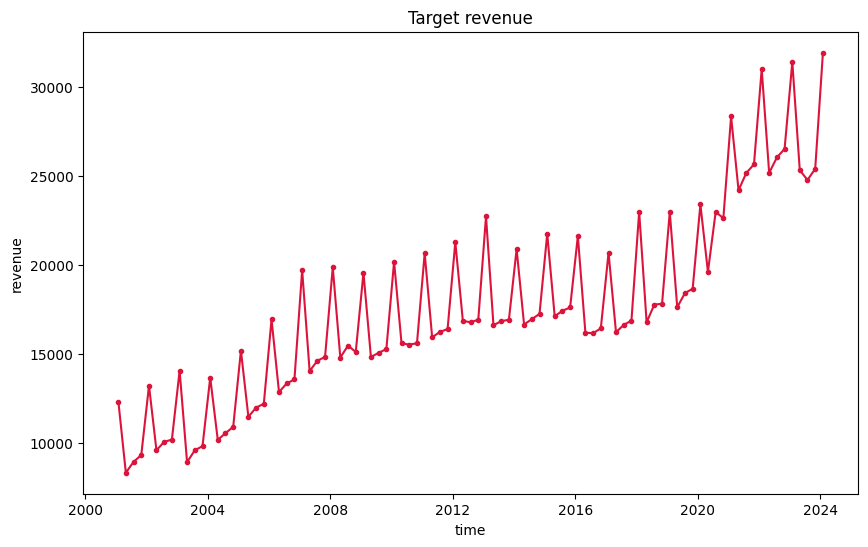

In [ ]:
#visualization initial
plt.figure(figsize=(10,6))

plt.title('Target revenue')
plt.xlabel('time')
plt.ylabel('revenue')

plt.plot(TargetSales['datadate'],TargetSales['saleq'],marker='.', color='crimson')

In [ ]:
TargetSales['time'] = range(1,len(TargetSales)+1)

/tmp/ipykernel_10591/100308816.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TargetSales['time'] = range(1,len(TargetSales)+1)


In [ ]:
#dummy variable 1 for holiday seasons
TargetSales['dummy_holidaytime'] = np.where(TargetSales['fqtr']==4, 1, 0)
TargetSales['interaction_holidaytime']=TargetSales['time']*TargetSales['dummy_holidaytime']

display(TargetSales)

/tmp/ipykernel_10591/3266735086.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TargetSales['time'] = range(1,len(TargetSales)+1)
/tmp/ipykernel_10591/3266735086.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TargetSales['dummy_holidaytime'] = np.where(TargetSales['fqtr']==4, 1, 0)
/tmp/ipykernel_10591/3266735086.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentat

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,dummy_holidaytime,time,interaction_holidaytime
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1,1,1
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,0,2,0
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,0,3,0
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,0,4,0
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,1,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,1,89,89
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,0,90,0
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,0,91,0
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,0,92,0


In [ ]:
TargetSales.loc[TargetSales['saleq']>25000]

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,dummy_holidaytime,time,interaction_holidaytime
172,3813,2021-01-31,2020,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2020Q4,2020Q4,28339.00,A,1,81,81
174,3813,2021-07-31,2021,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2021Q2,2021Q2,25160.00,A,0,83,0
175,3813,2021-10-31,2021,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2021Q3,2021Q3,25652.00,A,0,84,0
176,3813,2022-01-31,2021,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2021Q4,2021Q4,30996.00,A,1,85,85
177,3813,2022-04-30,2022,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q1,2022Q1,25170.00,A,0,86,0
178,3813,2022-07-31,2022,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q2,2022Q2,26037.00,A,0,87,0
179,3813,2022-10-31,2022,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q3,2022Q3,26518.00,A,0,88,0
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,1,89,89
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,0,90,0
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,0,92,0


In [ ]:
#dummy variable 1 for covid years
TargetSales['dummy_covidtime'] = np.where(TargetSales['datadate']>'2020-01-01', 1, 0)
TargetSales['interaction_covidtime']=TargetSales['time']*TargetSales['dummy_covidtime']

display(TargetSales)

/tmp/ipykernel_10591/1403686442.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TargetSales['dummy_covidtime'] = np.where(TargetSales['datadate']>'2020-01-01', 1, 0)
/tmp/ipykernel_10591/1403686442.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TargetSales['interaction_covidtime']=TargetSales['time']*TargetSales['dummy_covidtime']


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,...,curcdq,datacqtr,datafqtr,saleq,costat,dummy_holidaytime,time,interaction_holidaytime,dummy_covidtime,interaction_covidtime
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,...,USD,2000Q4,2000Q4,12324.00,A,1,1,1,0,0
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,...,USD,2001Q1,2001Q1,8334.00,A,0,2,0,0,0
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,...,USD,2001Q2,2001Q2,8941.00,A,0,3,0,0,0
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,...,USD,2001Q3,2001Q3,9331.00,A,0,4,0,0,0
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,...,USD,2001Q4,2001Q4,13220.00,A,1,5,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,...,USD,2022Q4,2022Q4,31395.00,A,1,89,89,1,89
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,...,USD,2023Q1,2023Q1,25322.00,A,0,90,0,1,90
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,...,USD,2023Q2,2023Q2,24773.00,A,0,91,0,1,91
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,...,USD,2023Q3,2023Q3,25398.00,A,0,92,0,1,92


In [ ]:
#to make training and testing dataframes
#take all before first 75 rows
dt4training2=TargetSales[:int(.75*len(TargetSales))]
#tak all after first 75 rows
dt4testing2=TargetSales[int(.75*len(TargetSales)):]

display(dt4training2)
display(dt4testing2)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,...,curcdq,datacqtr,datafqtr,saleq,costat,dummy_holidaytime,time,interaction_holidaytime,dummy_covidtime,interaction_covidtime
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,...,USD,2000Q4,2000Q4,12324.00,A,1,1,1,0,0
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,...,USD,2001Q1,2001Q1,8334.00,A,0,2,0,0,0
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,...,USD,2001Q2,2001Q2,8941.00,A,0,3,0,0,0
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,...,USD,2001Q3,2001Q3,9331.00,A,0,4,0,0,0
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,...,USD,2001Q4,2001Q4,13220.00,A,1,5,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,3813,2017-01-31,2016,4,1,INDL,C,D,STD,TGT,...,USD,2016Q4,2016Q4,20690.00,A,1,65,65,0,0
157,3813,2017-04-30,2017,1,1,INDL,C,D,STD,TGT,...,USD,2017Q1,2017Q1,16223.00,A,0,66,0,0,0
158,3813,2017-07-31,2017,2,1,INDL,C,D,STD,TGT,...,USD,2017Q2,2017Q2,16634.00,A,0,67,0,0,0
159,3813,2017-10-31,2017,3,1,INDL,C,D,STD,TGT,...,USD,2017Q3,2017Q3,16874.00,A,0,68,0,0,0


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,...,curcdq,datacqtr,datafqtr,saleq,costat,dummy_holidaytime,time,interaction_holidaytime,dummy_covidtime,interaction_covidtime
161,3813,2018-04-30,2018,1,1,INDL,C,D,STD,TGT,...,USD,2018Q1,2018Q1,16781.00,A,0,70,0,0,0
162,3813,2018-07-31,2018,2,1,INDL,C,D,STD,TGT,...,USD,2018Q2,2018Q2,17777.00,A,0,71,0,0,0
163,3813,2018-10-31,2018,3,1,INDL,C,D,STD,TGT,...,USD,2018Q3,2018Q3,17821.00,A,0,72,0,0,0
164,3813,2019-01-31,2018,4,1,INDL,C,D,STD,TGT,...,USD,2018Q4,2018Q4,22977.00,A,1,73,73,0,0
165,3813,2019-04-30,2019,1,1,INDL,C,D,STD,TGT,...,USD,2019Q1,2019Q1,17627.00,A,0,74,0,0,0
166,3813,2019-07-31,2019,2,1,INDL,C,D,STD,TGT,...,USD,2019Q2,2019Q2,18422.00,A,0,75,0,0,0
167,3813,2019-10-31,2019,3,1,INDL,C,D,STD,TGT,...,USD,2019Q3,2019Q3,18664.00,A,0,76,0,0,0
168,3813,2020-01-31,2019,4,1,INDL,C,D,STD,TGT,...,USD,2019Q4,2019Q4,23399.00,A,1,77,77,1,77
169,3813,2020-04-30,2020,1,1,INDL,C,D,STD,TGT,...,USD,2020Q1,2020Q1,19615.00,A,0,78,0,1,78
170,3813,2020-07-31,2020,2,1,INDL,C,D,STD,TGT,...,USD,2020Q2,2020Q2,22975.00,A,0,79,0,1,79


###model 1

In [ ]:
x2=dt4training2.loc[:,['time','dummy_holidaytime','interaction_holidaytime']]
x2=sm.add_constant(x2)

y1=dt4training2.loc[:,'saleq']

model_v1=sm.OLS(y1,x2).fit()
model_v1.params



,0
const,9470.64
time,134.90
dummy_holidaytime,4006.81
interaction_holidaytime,15.53


In [ ]:
x2_test = dt4testing2.loc[:,['time','dummy_holidaytime','interaction_holidaytime']]
x2_test = sm.add_constant(x2_test)

model_v1.predict(x2_test)

,0
161,18913.59
162,19048.49
163,19183.39
164,24458.49
165,19453.19
166,19588.09
167,19722.99
168,25060.19
169,19992.79
170,20127.69


In [ ]:
# final compare predicted to actual
# MAPE Score
# mean absolute percentage error

# step 1: copy testing data to new dataframe
# never want to mess with original or testing data

model_v1_assess = dt4testing2.copy()

# next add column with predicted revenue numbers to see alongside actuals
model_v1_assess['predict_revenue']=model_v1.predict(x2_test)

# see the difference according to MAPE
# find percentage error of each row and then find the mean of that
model_v1_assess['percentage_error']= abs( (model_v1_assess['saleq']-model_v1_assess['predict_revenue'])/model_v1_assess['saleq'] )


display(model_v1_assess)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,...,datafqtr,saleq,costat,dummy_holidaytime,time,interaction_holidaytime,dummy_covidtime,interaction_covidtime,predict_revenue,percentage_error
161,3813,2018-04-30,2018,1,1,INDL,C,D,STD,TGT,...,2018Q1,16781.00,A,0,70,0,0,0,18913.59,0.13
162,3813,2018-07-31,2018,2,1,INDL,C,D,STD,TGT,...,2018Q2,17777.00,A,0,71,0,0,0,19048.49,0.07
163,3813,2018-10-31,2018,3,1,INDL,C,D,STD,TGT,...,2018Q3,17821.00,A,0,72,0,0,0,19183.39,0.08
164,3813,2019-01-31,2018,4,1,INDL,C,D,STD,TGT,...,2018Q4,22977.00,A,1,73,73,0,0,24458.49,0.06
165,3813,2019-04-30,2019,1,1,INDL,C,D,STD,TGT,...,2019Q1,17627.00,A,0,74,0,0,0,19453.19,0.10
166,3813,2019-07-31,2019,2,1,INDL,C,D,STD,TGT,...,2019Q2,18422.00,A,0,75,0,0,0,19588.09,0.06
167,3813,2019-10-31,2019,3,1,INDL,C,D,STD,TGT,...,2019Q3,18664.00,A,0,76,0,0,0,19722.99,0.06
168,3813,2020-01-31,2019,4,1,INDL,C,D,STD,TGT,...,2019Q4,23399.00,A,1,77,77,1,77,25060.19,0.07
169,3813,2020-04-30,2020,1,1,INDL,C,D,STD,TGT,...,2020Q1,19615.00,A,0,78,0,1,78,19992.79,0.02
170,3813,2020-07-31,2020,2,1,INDL,C,D,STD,TGT,...,2020Q2,22975.00,A,0,79,0,1,79,20127.69,0.12


In [ ]:
model_v1_assess['percentage_error'].mean()

np.float64(0.12011310829121095)

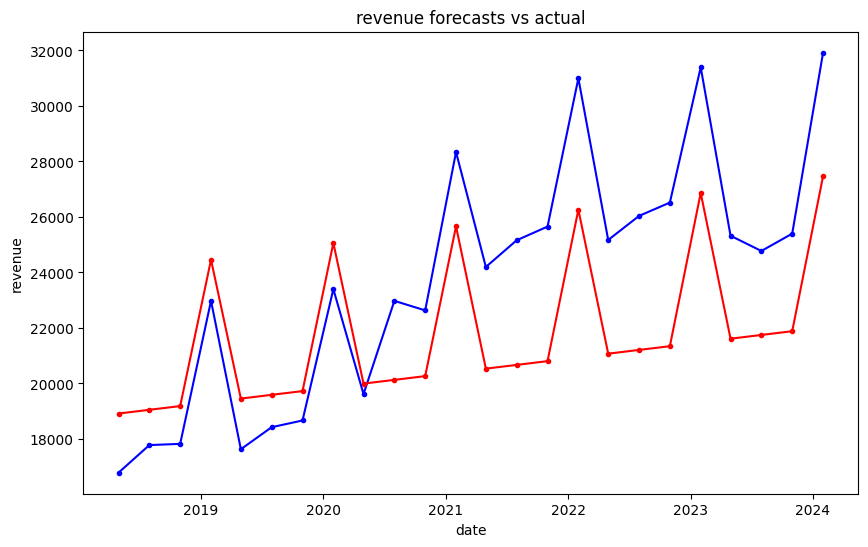

In [ ]:
# visualize both

plt.figure(figsize=(10,6))

plt.title('revenue forecasts vs actual')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model_v1_assess['datadate'],model_v1_assess['saleq'],marker='.', color = "blue")
plt.plot(model_v1_assess['datadate'],model_v1_assess['predict_revenue'],marker='.', color = 'red')

###model 2

In [ ]:
x3=dt4training2.loc[:,['time','dummy_covidtime','interaction_covidtime']]
x3=sm.add_constant(x3)

y2=dt4training2.loc[:,'saleq']

model_v2=sm.OLS(y2,x3).fit()
model_v2.params



,0
const,10503.75
time,139.30
dummy_covidtime,0.00
interaction_covidtime,0.00


In [ ]:
x3_test = dt4testing2.loc[:,['time','dummy_covidtime','interaction_covidtime']]
x3_test = sm.add_constant(x3_test)

model_v2.predict(x3_test)

,0
161,20254.51
162,20393.81
163,20533.11
164,20672.40
165,20811.70
166,20951.00
167,21090.29
168,21229.59
169,21368.89
170,21508.18


In [ ]:
# final compare predicted to actual
# MAPE Score
# mean absolute percentage error

# step 1: copy testing data to new dataframe
# never want to mess with original or testing data

model_v2_assess = dt4testing2.copy()

# next add column with predicted revenue numbers to see alongside actuals
model_v2_assess['predict_revenue']=model_v2.predict(x3_test)

# see the difference according to MAPE
# find percentage error of each row and then find the mean of that
model_v2_assess['percentage_error']= abs( (model_v2_assess['saleq']-model_v2_assess['predict_revenue'])/model_v2_assess['saleq'] )


display(model_v2_assess)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,...,datafqtr,saleq,costat,dummy_holidaytime,time,interaction_holidaytime,dummy_covidtime,interaction_covidtime,predict_revenue,percentage_error
161,3813,2018-04-30,2018,1,1,INDL,C,D,STD,TGT,...,2018Q1,16781.00,A,0,70,0,0,0,20254.51,0.21
162,3813,2018-07-31,2018,2,1,INDL,C,D,STD,TGT,...,2018Q2,17777.00,A,0,71,0,0,0,20393.81,0.15
163,3813,2018-10-31,2018,3,1,INDL,C,D,STD,TGT,...,2018Q3,17821.00,A,0,72,0,0,0,20533.11,0.15
164,3813,2019-01-31,2018,4,1,INDL,C,D,STD,TGT,...,2018Q4,22977.00,A,1,73,73,0,0,20672.40,0.10
165,3813,2019-04-30,2019,1,1,INDL,C,D,STD,TGT,...,2019Q1,17627.00,A,0,74,0,0,0,20811.70,0.18
166,3813,2019-07-31,2019,2,1,INDL,C,D,STD,TGT,...,2019Q2,18422.00,A,0,75,0,0,0,20951.00,0.14
167,3813,2019-10-31,2019,3,1,INDL,C,D,STD,TGT,...,2019Q3,18664.00,A,0,76,0,0,0,21090.29,0.13
168,3813,2020-01-31,2019,4,1,INDL,C,D,STD,TGT,...,2019Q4,23399.00,A,1,77,77,1,77,21229.59,0.09
169,3813,2020-04-30,2020,1,1,INDL,C,D,STD,TGT,...,2020Q1,19615.00,A,0,78,0,1,78,21368.89,0.09
170,3813,2020-07-31,2020,2,1,INDL,C,D,STD,TGT,...,2020Q2,22975.00,A,0,79,0,1,79,21508.18,0.06


In [ ]:
model_v2_assess['percentage_error'].mean()

np.float64(0.1398791010325449)

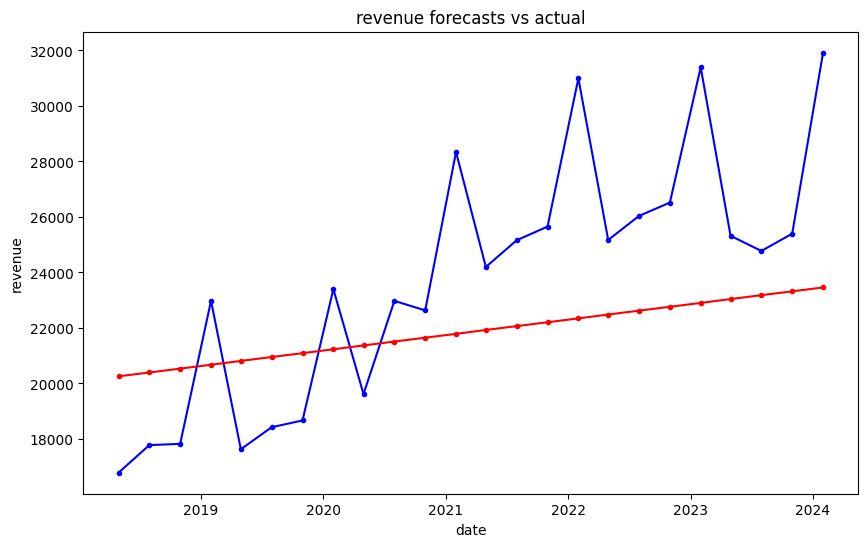

In [ ]:
# visualize both

plt.figure(figsize=(10,6))

plt.title('revenue forecasts vs actual')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model_v2_assess['datadate'],model_v2_assess['saleq'],marker='.', color = "blue")
plt.plot(model_v2_assess['datadate'],model_v2_assess['predict_revenue'],marker='.', color = 'red')

###model 3

In [ ]:
x4=dt4training2.loc[:,['time','dummy_holidaytime','interaction_holidaytime','dummy_covidtime','interaction_covidtime']]
x4=sm.add_constant(x4)

y3=dt4training2.loc[:,'saleq']

model_v3=sm.OLS(y3,x4).fit()
model_v3.params



,0
const,9470.64
time,134.90
dummy_holidaytime,4006.81
interaction_holidaytime,15.53
dummy_covidtime,0.00
interaction_covidtime,0.00


In [ ]:
x4_test = dt4testing2.loc[:,['time','dummy_holidaytime','interaction_holidaytime','dummy_covidtime','interaction_covidtime']]
x4_test = sm.add_constant(x4_test)

model_v3.predict(x4_test)

,0
161,18913.59
162,19048.49
163,19183.39
164,24458.49
165,19453.19
166,19588.09
167,19722.99
168,25060.19
169,19992.79
170,20127.69


In [ ]:
# final compare predicted to actual
# MAPE Score
# mean absolute percentage error

# step 1: copy testing data to new dataframe
# never want to mess with original or testing data

model_v3_assess = dt4testing2.copy()

# next add column with predicted revenue numbers to see alongside actuals
model_v3_assess['predict_revenue']=model_v3.predict(x4_test)

# see the difference according to MAPE
# find percentage error of each row and then find the mean of that
model_v3_assess['percentage_error']= abs( (model_v3_assess['saleq']-model_v3_assess['predict_revenue'])/model_v3_assess['saleq'] )


display(model_v3_assess)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,...,datafqtr,saleq,costat,dummy_holidaytime,time,interaction_holidaytime,dummy_covidtime,interaction_covidtime,predict_revenue,percentage_error
161,3813,2018-04-30,2018,1,1,INDL,C,D,STD,TGT,...,2018Q1,16781.00,A,0,70,0,0,0,18913.59,0.13
162,3813,2018-07-31,2018,2,1,INDL,C,D,STD,TGT,...,2018Q2,17777.00,A,0,71,0,0,0,19048.49,0.07
163,3813,2018-10-31,2018,3,1,INDL,C,D,STD,TGT,...,2018Q3,17821.00,A,0,72,0,0,0,19183.39,0.08
164,3813,2019-01-31,2018,4,1,INDL,C,D,STD,TGT,...,2018Q4,22977.00,A,1,73,73,0,0,24458.49,0.06
165,3813,2019-04-30,2019,1,1,INDL,C,D,STD,TGT,...,2019Q1,17627.00,A,0,74,0,0,0,19453.19,0.10
166,3813,2019-07-31,2019,2,1,INDL,C,D,STD,TGT,...,2019Q2,18422.00,A,0,75,0,0,0,19588.09,0.06
167,3813,2019-10-31,2019,3,1,INDL,C,D,STD,TGT,...,2019Q3,18664.00,A,0,76,0,0,0,19722.99,0.06
168,3813,2020-01-31,2019,4,1,INDL,C,D,STD,TGT,...,2019Q4,23399.00,A,1,77,77,1,77,25060.19,0.07
169,3813,2020-04-30,2020,1,1,INDL,C,D,STD,TGT,...,2020Q1,19615.00,A,0,78,0,1,78,19992.79,0.02
170,3813,2020-07-31,2020,2,1,INDL,C,D,STD,TGT,...,2020Q2,22975.00,A,0,79,0,1,79,20127.69,0.12


In [ ]:
model_v3_assess['percentage_error'].mean()

np.float64(0.12011310829121091)

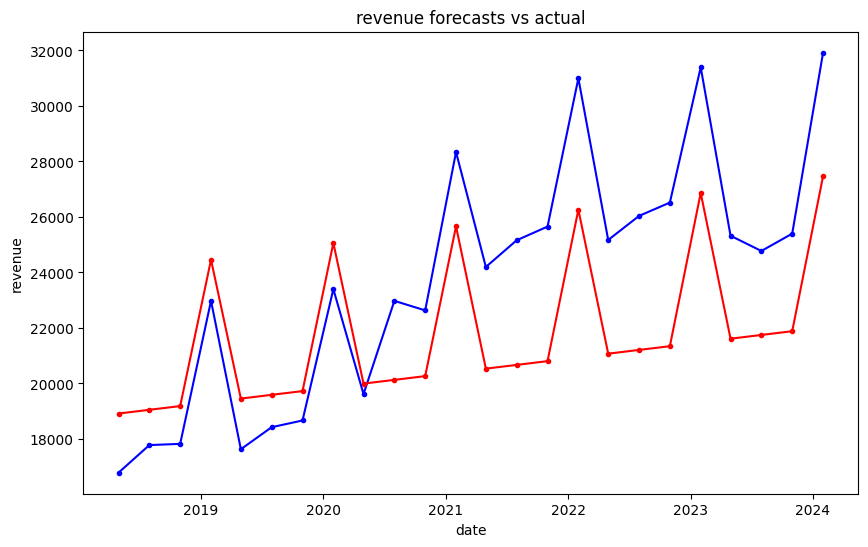

In [ ]:
# visualize both

plt.figure(figsize=(10,6))

plt.title('revenue forecasts vs actual')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model_v3_assess['datadate'],model_v3_assess['saleq'],marker='.', color = "blue")
plt.plot(model_v3_assess['datadate'],model_v3_assess['predict_revenue'],marker='.', color = 'red')

###The chosen one (AKA Model 1 due to lowest MAPE score and it makes better sense based on visualizaiton)

In [ ]:
testing_out = {
    "datadate": ["2024-04-30", "2024-07-31", "2024-10-31","2025-01-31"],
    "time": [94, 95, 96, 97],
    "dummy_holidaytime":[0,0 ,0 ,1]
}
# Create the DataFrame
testing_4Q_out = pd.DataFrame(testing_out)


In [ ]:
testing_4Q_out['interaction_holidaytime']=testing_4Q_out['time']*testing_4Q_out['dummy_holidaytime']

In [ ]:
display(testing_4Q_out)

,datadate,time,dummy_holidaytime,interaction_holidaytime
0,2024-04-30,94,0,0
1,2024-07-31,95,0,0
2,2024-10-31,96,0,0
3,2025-01-31,97,1,97


In [ ]:
x_chosen_test = testing_4Q_out.loc[:,['time','dummy_holidaytime','interaction_holidaytime']]
x_chosen_test = sm.add_constant(x_chosen_test)

In [ ]:
model_chosen_assess = testing_4Q_out.copy()

# next add column with predicted revenue numbers to see alongside actuals
model_chosen_assess['predict_revenue']=model_v1.predict(x_chosen_test)

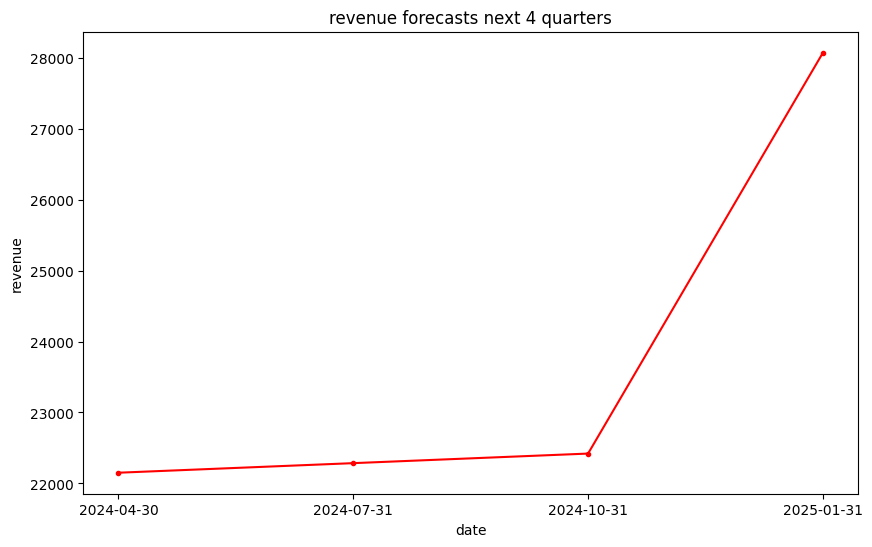

In [ ]:
plt.figure(figsize=(10,6))

plt.title('revenue forecasts next 4 quarters')
plt.xlabel('date')
plt.ylabel('revenue')
plt.plot(model_chosen_assess['datadate'],model_chosen_assess['predict_revenue'],marker='.', color = 'red')